In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Set visual style for professional charts
sns.set_theme(style="whitegrid")

# 1. Automatically locate the downloaded CSV
raw_data_dir = '../data/raw'
csv_files = [f for f in os.listdir(raw_data_dir) if f.endswith('.csv')]
file_path = os.path.join(raw_data_dir, csv_files[0])
print(f"Loading dataset: {csv_files[0]}\n")

# Load the data
df = pd.read_csv(file_path)

# 2. The Baseline Audit
print("--- DATAFRAME SHAPE ---")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

print("--- DATA TYPES & MISSING VALUES ---")
df.info()

# Display the first 5 rows to inspect the columns (especially the CustomerFeedback column)
df.head()

Loading dataset: telco_churn_with_all_feedback.csv

--- DATAFRAME SHAPE ---
Rows: 7043, Columns: 23

--- DATA TYPES & MISSING VALUES ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14 

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn,PromptInput,CustomerFeedback
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No,Write a realistic customer feedback based on t...,I have been using the DSL internet service fro...
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,No,No,One year,No,Mailed check,56.95,1889.5,No,Write a realistic customer feedback based on t...,I have been a customer with this company for o...
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,Write a realistic customer feedback based on t...,I recently signed up for DSL internet service ...
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No,Write a realistic customer feedback based on t...,I have been a loyal customer with this company...
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,Write a realistic customer feedback based on t...,I recently switched to this fiber optic intern...


Exposed 11 hidden blank values in TotalCharges. Dropping them.



D:\Temporary\ipykernel_14164\4049323852.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='Churn', data=df, palette='viridis')


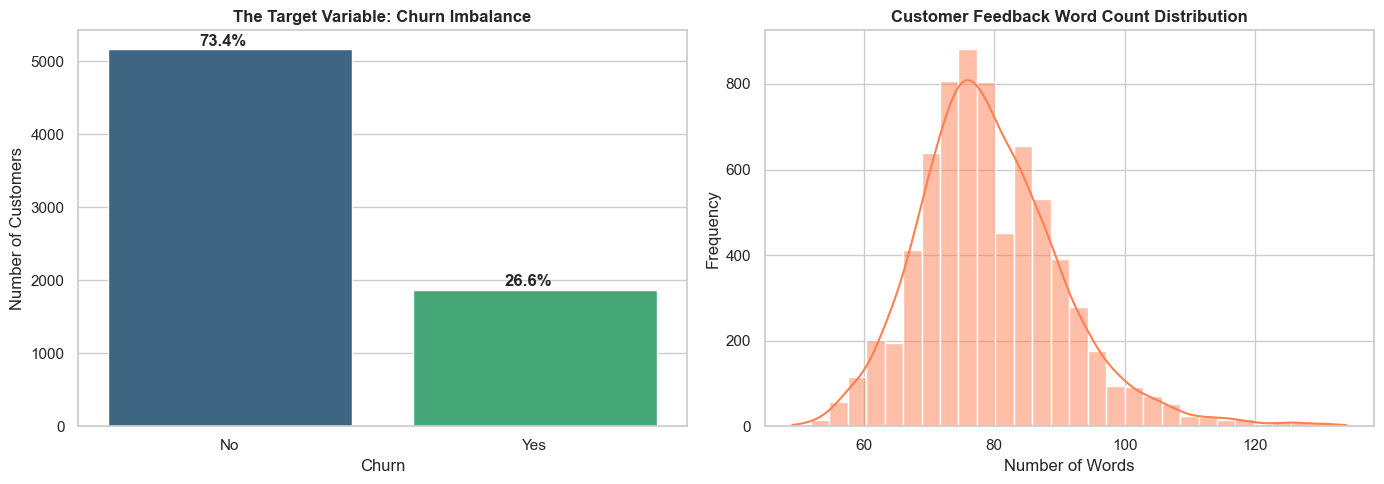

--- CLEANED DATAFRAME INFO ---
<class 'pandas.core.frame.DataFrame'>
Index: 7032 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   gender               7032 non-null   object 
 1   SeniorCitizen        7032 non-null   int64  
 2   Partner              7032 non-null   object 
 3   Dependents           7032 non-null   object 
 4   tenure               7032 non-null   int64  
 5   PhoneService         7032 non-null   object 
 6   MultipleLines        7032 non-null   object 
 7   InternetService      7032 non-null   object 
 8   OnlineSecurity       7032 non-null   object 
 9   OnlineBackup         7032 non-null   object 
 10  DeviceProtection     7032 non-null   object 
 11  TechSupport          7032 non-null   object 
 12  StreamingTV          7032 non-null   object 
 13  StreamingMovies      7032 non-null   object 
 14  Contract             7032 non-null   object 
 15  PaperlessBil

In [6]:
# 1. THE FIX: Convert TotalCharges to numeric, forcing errors (blank spaces) to NaN
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many blank spaces we just exposed
null_charges = df['TotalCharges'].isnull().sum()
print(f"Exposed {null_charges} hidden blank values in TotalCharges. Dropping them.\n")

# Drop those rows (it's usually only ~11 rows out of 7000, statistically negligible)
df.dropna(subset=['TotalCharges'], inplace=True)

# Drop useless metadata columns
df.drop(columns=['customerID', 'PromptInput'], inplace=True, errors='ignore')

# 2. IMBALANCE QUANTIFICATION
plt.figure(figsize=(14, 5))

# Subplot 1: Churn Imbalance
plt.subplot(1, 2, 1)
ax = sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('The Target Variable: Churn Imbalance', fontweight='bold')
plt.ylabel('Number of Customers')

# Add percentage labels on top of the bars
total = len(df)
for p in ax.patches:
    percentage = f'{100 * p.get_height() / total:.1f}%'
    x = p.get_x() + p.get_width() / 2 - 0.1
    y = p.get_y() + p.get_height() + 50
    ax.annotate(percentage, (x, y), fontweight='bold')

# 3. UNSTRUCTURED DATA INSPECTION (NLP EDA)
# Calculate the word count for each piece of customer feedback
df['feedback_word_count'] = df['CustomerFeedback'].apply(lambda x: len(str(x).split()))

# Subplot 2: Feedback Length Distribution
plt.subplot(1, 2, 2)
sns.histplot(df['feedback_word_count'], bins=30, kde=True, color='coral')
plt.title('Customer Feedback Word Count Distribution', fontweight='bold')
plt.xlabel('Number of Words')
plt.ylabel('Frequency')

plt.tight_layout()
plt.show()

print("--- CLEANED DATAFRAME INFO ---")
df.info()

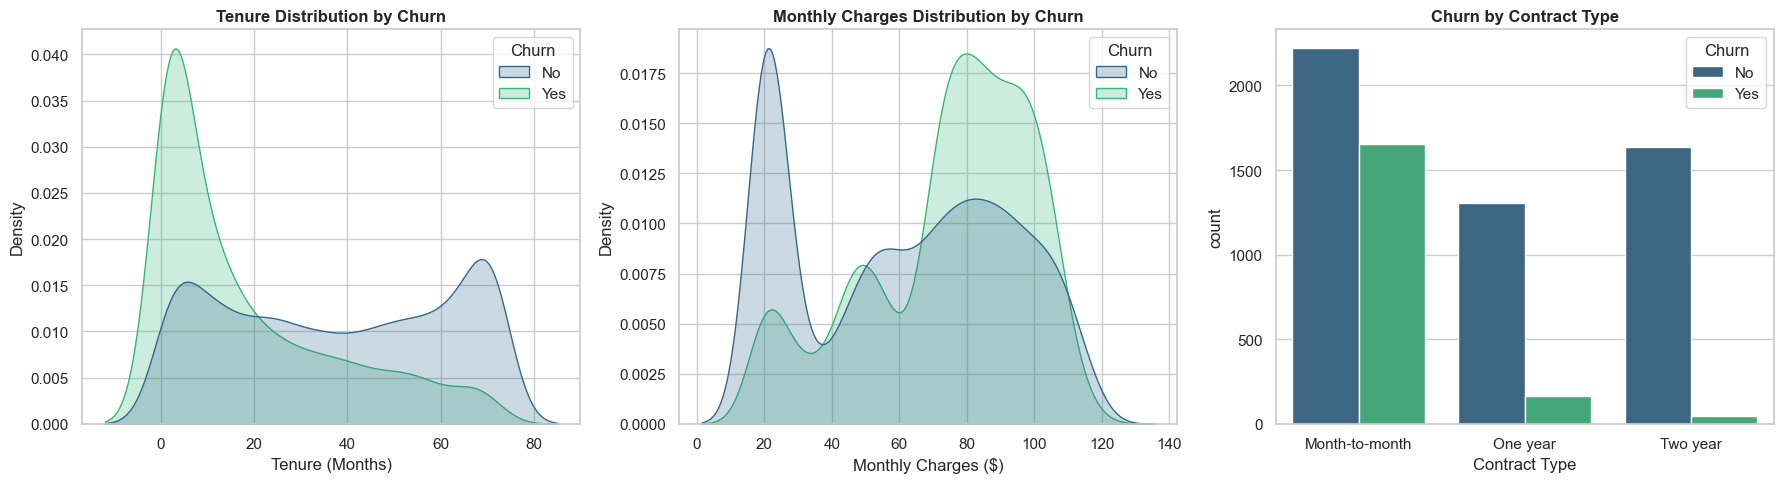

In [7]:
# 4. TABULAR VISUALIZATIONS: Identifying the drivers of Churn
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot 1: Tenure vs Churn
sns.kdeplot(data=df, x='tenure', hue='Churn', common_norm=False, fill=True, palette='viridis', ax=axes[0])
axes[0].set_title('Tenure Distribution by Churn', fontweight='bold')
axes[0].set_xlabel('Tenure (Months)')

# Plot 2: Monthly Charges vs Churn
sns.kdeplot(data=df, x='MonthlyCharges', hue='Churn', common_norm=False, fill=True, palette='viridis', ax=axes[1])
axes[1].set_title('Monthly Charges Distribution by Churn', fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)')

# Plot 3: Contract Type vs Churn
sns.countplot(data=df, x='Contract', hue='Churn', palette='viridis', ax=axes[2])
axes[2].set_title('Churn by Contract Type', fontweight='bold')
axes[2].set_xlabel('Contract Type')

plt.tight_layout()
plt.show()